### Load the SigmaProfile Prediction Model

In [1]:
from __future__ import absolute_import
import os


import sys, random, pickle, csv, time
import torch
import torch.nn as nn
from torch.utils.data.sampler import SubsetRandomSampler
import numpy as np
import pandas as pd
from torch.optim.lr_scheduler import ReduceLROnPlateau as reduce_lr
import matplotlib.pyplot as plt
import wandb
import argparse
import math
import xgboost

# internal imports
from train_water_solubility import AccumulationMeter
from util_water.generate_dataset_for_training_water import solute_dataset_water, solute_dataset_water_SP, collate_solute_water, collate_solute_water_SP
from util.generate_dataset_for_training import solvent_dataset_ternary, collate_solvent_ternary
from model.model_GNN_water import water_gegnn, water_gegnn_no_Pooling, water_gegnn_SigmaProfile_noPooling, RittigPure, AbranchesPure, Rittig_Abranches, RA_var_opt, RA_opt, RittigPure_opt
from model.model_GNN import Qin_ternary, Qin_ternary_optimized

In [12]:
### establish the hyperparameters used for the training/validation stage

#RittigPure path
#model_type = 'RittigPure'
#PATH = "C:/Users/kverg/GDI-NN/results_water/Complete_trainset_final_model__SolubilityWater_RittigPure_actsoftplus_encActrelu_lrschedTrue_epochs100_lr0.001_L2coef_0_batchsize100_earlystopping_False.pth"

model_type = 'RittigPure_optimized'
PATH = 'C:/Users/kverg/GDI-NN/results_water/Complete_trainset_final_model__RittigPure_optimized_lrschedTrue_epochs70_lr0.001_L2coef1e-05_batchsize100__weightNone_gcnDim156_mpnnDim128_mlpDim134.pth'

#AbranchesPure path - complete dataset train
#PATH = "C:/Users/kverg/GDI-NN/results_water/Complete_trainset_final_model__SolubilityWater_AbranchesPure_actswish_encActrelu_lrschedFalse_epochs100_lr0.00077_L2coef0.0002_batchsize100_earlystopFalse_normTrue_weightuniform_checkpointTrue.pth"

#AbranchesPure path - only based on 1 fold of the 5-fold CV
#PATH = "C:/Users/kverg/GDI-NN/results_water/final_model_cv0_solubilityWater_split-stratHybrid_nums5-AbranchesPure_hiddenDim_0_dropout0_actswish_encActrelu_nhl1_lrschedFalse_epochs200_lr0.00077_L2coef0.0002_batchsize100_mespass0_normTrue.pth"

#Rittig_Abranches path
#PATH = "C:/Users/kverg/GDI-NN/results_water/Complete_trainset_final_model__SolubilityWater_Rittig_Abranches_actsoftplus_encActrelu_lrschedTrue_epochs100_lr0.001_L2coef1e-05_batchsize100_earlystopFalse_normFalse_weightNone_checkpointFalse.pth"

#Rittig_Abranches_variant path
#PATH = "C:/Users/kverg/GDI-NN/results_water/Complete_trainset_final_model__SolubilityWater_water_gegnn_SigmaProfile_noPooling_actsoftplus_encActrelu_lrschedTrue_epochs50_lr0.001_L2coef_1e-05_batchsize100_earlystopping_False.pth"

#model_type = 'Rittig_Abranches_optimized'
#PATH = 'C:/Users/kverg/GDI-NN/results_water/Complete_trainset_final_model__Rittig_Abranches_optimized_lrschedTrue_epochs70_lr0.001_L2coef1e-05_batchsize100__weightNone_gcnDim270_mpnnDim190_mlpDim290_nconvfilters6_kernelsize4_poolsize10_SPdim7.pth'

#model_type = 'Rittig_Abranches_variant_optimized'
#PATH = "C:/Users/kverg/GDI-NN/results_water/Complete_trainset_final_model__Rittig_Abranches_variant_optimized_lrschedTrue_epochs70_lr0.0004173_L2coef4.046e-10_batchsize80__weightNone_gcnDim282_mpnnDim198_mlpDim119.pth"

model_type = 'Qin_ternary_optimized'
PATH = 'results_inf/final_model_wholeTrain__solub_inf_binary_nums0-Qin_ternary_optimized_pinn_l1.0_se0_dropout0.0_actsoftplus_encActrelu_gcndim124_mpnndim235_mlpdim94_nhl0_batchAFalse_lrschedTrue_epochs100_lr0.001_batchsize100_mespas1.pth'

model_type = 'Qin_ternary_optimized'
PATH = 'results_inf/final_model_wholeTrain__solub_inf_binary_nums0-Qin_ternary_optimized_pinn_l1.0_se0_dropout0.0_actsoftplus_encActrelu_gcndim281_mpnndim296_mlpdim250_nhl0_batchAFalse_lrschedTrue_epochs100_lr0.001_batchsize100_mespas1.pth'

model_type = 'Qin_ternary'
PATH = 'results_inf/final_model_wholeTrain__solub_inf_binary_split-system_extra_nums0-Qin_ternary_pinn_l1.0_se0_dropout0.0_actsoftplus_encActrelu_nhl0_batchAFalse_lrschedTrue_epochs100_lr0.001_batchsize100_messagepassingsteps1.pth'

#model_type = 'hybrid_XGB'

# model parameters, if not used state None
use_SP = False
use_emptysolvsys = True
water_model = False

device = torch.device("cuda:0")
gcn_dim = 124
mpnn_dim = 235
mlp_dim = 94
hidden_dim = 256
mlp_activation = 'softplus'
enc_activation = 'relu'
mlp_dropout_rate = 0
mlp_num_hid_layers = 2
sigma_profile_model_path = "C:/Users/kverg/GDI-NN/SigmaProfileModel/results_SP/Complete_trainset_final_model__MMFF_sp_Database_Sigma_profile_prediction_actrelu_encActrelu_lrschedFalse_epochs700_lr0.00151_L2coef_7.79e-06_batchsize16_earlystopping_False.pth"
weight_init = 'None'
num_step_message_passing = 1
normalize = False
n_conv_filters = 6
kernel_size = 4
pool_size = 10
SP_dim = 7

batch_size = 999

n_estimators = 49
eta = 7.6343e-2
max_depth = 4
n_jobs = 8

seed = 2025
if weight_init == 'uniform':
    torch.manual_seed(seed)
    weight_init = torch.nn.init.uniform_
else:
    weight_init = None

In [13]:
if model_type == "water_gegnn":
    model = water_gegnn(in_dim=74, hidden_dim=hidden_dim, n_classes=1, mlp_activation=mlp_activation, mpnn_activation=enc_activation).cuda()
    model.load_state_dict(torch.load(PATH)["model_state_dict"])
elif model_type == "water_gegnn_no_Pooling": 
    model = water_gegnn_no_Pooling(in_dim=74, hidden_dim=hidden_dim, n_classes=1, mlp_dropout_rate=mlp_dropout_rate, mlp_activation=mlp_activation, mlp_num_hid_layers=mlp_num_hid_layers).cuda()
    model.load_state_dict(torch.load(PATH)["model_state_dict"])
elif model_type == "water_gegnn_SigmaProfile_noPooling": 
    model = water_gegnn_SigmaProfile_noPooling(in_dim=74, hidden_dim=hidden_dim, n_classes=1, mlp_dropout_rate=mlp_dropout_rate, mlp_activation=mlp_activation, mlp_num_hid_layers=mlp_num_hid_layers, num_step_message_passing=num_step_message_passing).cuda()
    model.load_state_dict(torch.load(PATH)["model_state_dict"])
elif model_type == "RittigPure":
    model = RittigPure(in_dim=74, hidden_dim=hidden_dim, n_classes=1, mlp_dropout_rate=0, mlp_activation=mlp_activation, mpnn_activation=enc_activation, mlp_num_hid_layers=2, num_step_message_passing=1).cuda()
    model.load_state_dict(torch.load(PATH)["model_state_dict"])
elif model_type == "RittigPure_optimized": 
    model = RittigPure_opt(in_dim=74, gcn_dim=gcn_dim, mpnn_dim=mpnn_dim, mlp_dim=mlp_dim, n_classes=1, mpnn_activation=enc_activation, mlp_activation=mlp_activation, mlp_num_hid_layers=mlp_num_hid_layers,
                               num_step_message_passing=num_step_message_passing, device=device).cuda()
    model.load_state_dict(torch.load(PATH)["model_state_dict"])
elif model_type == "AbranchesPure":
    model = AbranchesPure(in_dim=50, n_classes=1, sigma_profile_model_path=sigma_profile_model_path, weight_init=weight_init, sigma_profile_length=51).cuda()
    model.load_state_dict(torch.load(PATH)["model_state_dict"])
elif model_type == "Rittig_Abranches":
    model = Rittig_Abranches(in_dim_rit=74, in_dim_abr=50, n_classes=1, weight_init=weight_init, sigma_profile_length=51, hidden_dim=hidden_dim,
                                     mpnn_activation=enc_activation, num_step_message_passing=num_step_message_passing, mlp_dropout_rate=mlp_dropout_rate,
                                     mlp_num_hid_layers=mlp_num_hid_layers, mlp_activation=mlp_activation,
                                     sigma_profile_model_path=sigma_profile_model_path).cuda()
    model.load_state_dict(torch.load(PATH)["model_state_dict"])
elif model_type == "Rittig_Abranches_optimized":
    model = RA_opt(in_dim_rit=74, in_dim_abr=50, n_classes=1, sigma_profile_length=51, weight_init_fn=weight_init,
                        mpnn_activation= enc_activation, num_step_message_passing=num_step_message_passing, mlp_activation=mlp_activation,
                        mlp_num_hid_layers=mlp_num_hid_layers,
                        gcn_dim=gcn_dim, mpnn_dim=mpnn_dim, mlp_dim=mlp_dim,
                        n_conv_filters=n_conv_filters, kernel_size=kernel_size, pool_size=pool_size, SP_dim=SP_dim,
                        device=device,
                        sigma_profile_model_path=sigma_profile_model_path).to(device)
    model.load_state_dict(torch.load(PATH)["model_state_dict"])
elif model_type == "Rittig_Abranches_variant_optimized":
    model = RA_var_opt(in_dim_rit=74, in_dim_abr=50, n_classes=1, sigma_profile_length=51, weight_init_fn=weight_init,
                            mpnn_activation=enc_activation, num_step_message_passing=num_step_message_passing, mlp_activation=mlp_activation,
                            mlp_num_hid_layers=mlp_num_hid_layers,
                            gcn_dim=gcn_dim, mpnn_dim=mpnn_dim, mlp_dim=mlp_dim,
                            device=device,
                            sigma_profile_model_path=sigma_profile_model_path).to(device)
    model.load_state_dict(torch.load(PATH)["model_state_dict"])
elif model_type == "Qin_ternary":
    model = Qin_ternary(in_dim=74, hidden_dim=hidden_dim, n_classes=2, mlp_activation=mlp_activation).to(device)
    model.load_state_dict(torch.load(PATH)["model_state_dict"])
elif model_type == "Qin_ternary_optimized":
    model = Qin_ternary_optimized(in_dim=74, gcn_dim=gcn_dim, mpnn_dim=mpnn_dim, mlp_dim=mlp_dim, n_classes=2, mlp_activation=mlp_activation).to(device)
    model.load_state_dict(torch.load(PATH)["model_state_dict"])

elif model_type == 'hybrid_XGB':
    model_NN = RA_var_opt(in_dim_rit=74, in_dim_abr=50, n_classes=1, sigma_profile_length=51, weight_init_fn=weight_init,
                            mpnn_activation=enc_activation, num_step_message_passing=num_step_message_passing, mlp_activation=mlp_activation,
                            mlp_num_hid_layers=mlp_num_hid_layers,
                            gcn_dim=gcn_dim, mpnn_dim=mpnn_dim, mlp_dim=mlp_dim,
                            device=device,
                            sigma_profile_model_path=sigma_profile_model_path).to(device)
    model_XGB = xgboost.XGBRegressor(n_estimators=n_estimators,
                                     learning_rate=eta,
                                     max_depth=max_depth,
                                     n_jobs=n_jobs,
                                     device='cpu')
    model_NN_load_str = 'C:/Users/kverg/GDI-NN/results_water/Complete_trainset_final_model__Rittig_Abranches_variant_optimized_lrschedTrue_epochs70_lr0.0004173_L2coef4.046e-10_batchsize80__weightNone_gcnDim282_mpnnDim198_mlpDim119.pth'
    model_NN.load_state_dict(torch.load(model_NN_load_str, weights_only=True)["model_state_dict"])
    model_XGB.load_model('C:/Users/kverg/GDI-NN/results_hybrids/hybXGB_nestim49_eta0.076343_maxdepth4_gcndim282_mpnndim198_mlpdim119_actsoftplus_encActrelu_nhl2_lrschedTrue_epochs70_lr0.0004173_L2coef4.046e-10_batchsize80_mespass1_normFalse_WIuniform.bst')
    activation = {}
    def get_activation(name):
        def hook(model, input, output):
            activation[name] = output.detach()
        return hook
    model_NN.mfp_trans.register_forward_hook(get_activation('mfp_trans'))

C:\Users\kverg\AppData\Local\Temp\ipykernel_17900\3935621233.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(PATH)["model_state_dict"])

In [4]:
# read dataset file
if water_model:
    dataset_path = './data/solubility_water/COMPATIBLE_unique_test_water_with_hybrid_classes.csv'
    solute_list_path = './data/solubility_water/solute_list_with_polarity_and_size.csv'
    solvent_list_path = './data/solubility_water/solvent_list_water_with_polarity_and_size.csv'
    if use_SP:
        dataset_class = solute_dataset_water_SP
        collate_fn = collate_solute_water_SP
    else:
        dataset_class = solute_dataset_water
        collate_fn = collate_solute_water
    dataset = dataset_class(
        input_file_path=dataset_path,
        solute_list_path=solute_list_path,
        solvent_list_path=solvent_list_path,
        generate_all=True,
        normalize=False)

else:
    dataset_path = "C:/Users/kverg/GDI-NN/data/infinite_dilution_activity_ternary/systems_test_old_old.csv"
    solvent_list_path = "C:/Users/kverg/GDI-NN/data/infinite_dilution_activity_ternary/solvent_list_solub.csv"
    solute_list_path = "C:/Users/kverg/GDI-NN/data/infinite_dilution_activity_ternary/solute_list_solub.csv"
    dataset_class = solvent_dataset_ternary
    collate_fn = collate_solvent_ternary
    dataset = dataset_class(
        input_file_path=dataset_path,
        solute_list_path=solute_list_path,
        solvent_list_path=solvent_list_path,
        generate_all=True)
    
dataset_size = len(dataset)
        
# print dataset size
print('dataset size: {}'.format(dataset_size))

test_indices = np.arange(dataset_size)
# Dataloader

if batch_size == 'dataset_size':
    batch_size = dataset_size

test_sampler = SubsetRandomSampler(test_indices)
test_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                                sampler=test_sampler,
                                                collate_fn=collate_fn,
                                                shuffle=False,
                                                drop_last=True)
if use_emptysolvsys:
    empty_solvsys = dataset.generate_solvsys(batch_size).to(device)
else:
    empty_solvsys = None
print(len(test_loader))

c:\Users\kverg\miniforge3\envs\GDINN1\lib\site-packages\dgl\heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


dataset size: 4995
5


In [5]:
def test_water(test_loader, model, empty_solvsys, normalize, dataset_used_in_training_path, device):
    if normalize:
        df_train = pd.read_csv(dataset_used_in_training_path)
        df_train['LogS'] = [math.pow(10,x)/0.997 for x in df_train['LogS'].tolist()]
        logS_mod = np.array([math.log(x,10) for x in df_train['LogS'].tolist()])
    stage = 'test'
    loss_fn1 = nn.MSELoss()
    loss_fn2 = nn.L1Loss()
    loss1_accum = AccumulationMeter()
    loss2_accum = AccumulationMeter()
    test_pred = torch.tensor([]).cpu()
    test_true = torch.tensor([]).cpu()
    model.eval()
    with torch.set_grad_enabled(True):
        for i, component_data in enumerate(test_loader):
            lablogS = component_data['LogS'].float().to(device) 
            output = None
            with torch.backends.cudnn.flags(enabled=False):
                if empty_solvsys != None:
                    output = model(component_data, empty_solvsys, device)
                else:
                    output = model(component_data, device)
                if normalize:
                    output = output*np.std(logS_mod)+np.mean(logS_mod)
                    output = torch.pow(10,output)*0.997
                    output = torch.log10(output)
            loss1 = loss_fn1(output[:,0],lablogS)
            loss1_accum.update(loss1.item(),lablogS.size(0))
            loss2 = loss_fn2(output[:,0],lablogS)
            loss2_accum.update(loss2.item(),lablogS.size(0))
            test_pred = torch.concatenate([test_pred, output.detach().cpu()])
            test_true = torch.concatenate([test_true, lablogS.detach().cpu()])
    #breakpoint()
    print("[Stage {}]: RMSE={:.3f}, MAE={:.3f}".format(
            stage, np.sqrt(np.array(loss1_accum.avg)), loss2_accum.avg))

    return test_pred, test_true, [np.sqrt(np.array(loss1_accum.avg)), loss2_accum.avg]

In [184]:
def test_water_hybrid(test_loader, model_nn, model_xgb, empty_solvsys, normalize, dataset_used_in_training_path, dataset_size, device):
    if normalize:
        df_train = pd.read_csv(dataset_used_in_training_path)
        df_train['LogS'] = [math.pow(10,x)/0.997 for x in df_train['LogS'].tolist()]
        logS_mod = np.array([math.log(x,10) for x in df_train['LogS'].tolist()])
    stage = 'test'
    loss_fn1 = nn.MSELoss()
    loss_fn2 = nn.L1Loss()
    loss1_accum = AccumulationMeter()
    loss2_accum = AccumulationMeter()
    test_pred = torch.tensor([]).cpu()
    test_true = torch.tensor([]).cpu()
    test_indices = np.arange(dataset_size)
    output_array_NN = torch.tensor([])
    target_array = torch.tensor([])
    XGB_input_array = torch.tensor([])
    empty_solvsys = dataset.generate_solvsys(len(test_indices)).to("cpu")
    model_nn.eval()
    with torch.set_grad_enabled(True):
        for i, component_data in enumerate(test_loader):
            lablogS = component_data['LogS'].float().to(device)
            output = None
            with torch.backends.cudnn.flags(enabled=False):
                if empty_solvsys != None:
                    output = model_nn(component_data, empty_solvsys, device)
                    XGB_input = activation['mfp_trans'].detach()
                else:
                    output = model_nn(component_data, device)
                    XGB_input = activation['mfp_trans'].detach()
                if normalize:
                    XGB_input = XGB_input*np.std(logS_mod)+np.mean(logS_mod)
                    XGB_input = torch.pow(10,XGB_input)*0.997
                    XGB_input = torch.log10(XGB_input)
            output_array_NN = torch.concatenate([output_array_NN, output])
            target_array = torch.concatenate([target_array, lablogS])
            XGB_input_array = torch.concatenate([XGB_input_array, XGB_input])
            
        target_array = target_array.numpy()
        XGB_input_array = XGB_input_array.numpy()

        predicted_array = model_xgb.predict(XGB_input_array)

        xgb_mse = ((target_array - predicted_array)**2).mean()
        xgb_mae = np.abs(target_array - predicted_array).mean()

            #loss1 = loss_fn1(output[:,0],lablogS)
            #loss1_accum.update(loss1.item(),lablogS.size(0))
            #loss2 = loss_fn2(output[:,0],lablogS)
            #loss2_accum.update(loss2.item(),lablogS.size(0))
            #test_pred = torch.concatenate([test_pred, output.detach().cpu()])
            #test_true = torch.concatenate([test_true, lablogS.detach().cpu()])
    #breakpoint()
    print("[Stage {}]: RMSE={:.4f}, MAE={:.4f}".format(
            stage, np.sqrt(np.array(xgb_mse)), xgb_mae))

    return predicted_array, target_array, xgb_mse, xgb_mae

In [5]:
def test_act(test_loader, model, empty_solvsys, device):
    stage = 'test'
    loss_fn1 = nn.MSELoss()
    loss_fn2 = nn.L1Loss()
    loss_mse_total_accum = AccumulationMeter()
    loss_mse_1_accum = AccumulationMeter()
    loss_mse_2_accum = AccumulationMeter()
    loss_mse_3_accum = AccumulationMeter()
    loss_mae_total_accum = AccumulationMeter()
    loss_mae_1_accum = AccumulationMeter()
    loss_mae_2_accum = AccumulationMeter()
    loss_mae_3_accum = AccumulationMeter()
    test_pred_1 = torch.tensor([]).cpu()
    test_pred_2 = torch.tensor([]).cpu()
    test_pred_3 = torch.tensor([]).cpu()
    test_true_1 = torch.tensor([]).cpu()
    test_true_2 = torch.tensor([]).cpu()
    test_true_3 = torch.tensor([]).cpu()
    model.eval()
    with torch.set_grad_enabled(True):
        for i, component_data in enumerate(test_loader):
            labgam1 = component_data['gamma1'].float().cuda()
            labgam2 = component_data['gamma2'].float().cuda()
            labgam3 = component_data['gamma3'].float().cuda()
            output = None
            with torch.backends.cudnn.flags(enabled=False):
                if empty_solvsys != None:
                    output, _, _ = model(component_data, empty_solvsys, device)
                else:
                    output, _, _ = model(component_data, device)
                
            loss_mse_1 = loss_fn1(output[:,0],labgam1)
            loss_mse_1_accum.update(loss_mse_1.item(),labgam1.size(0))
            loss_mse_2 = loss_fn1(output[:,1],labgam2)
            loss_mse_2_accum.update(loss_mse_2.item(),labgam2.size(0))
            loss_mse_3 = loss_fn1(output[:,2],labgam3)
            loss_mse_3_accum.update(loss_mse_3.item(),labgam3.size(0))

            loss_mse_total = loss_mse_1*1/3 + loss_mse_2*1/3 + loss_mse_3*1/3
            loss_mse_total_accum.update(loss_mse_total.item(),labgam1.size(0))

            loss_mae_1 = loss_fn2(output[:,0],labgam1)
            loss_mae_1_accum.update(loss_mae_1.item(),labgam1.size(0))
            loss_mae_2 = loss_fn2(output[:,1],labgam2)
            loss_mae_2_accum.update(loss_mae_2.item(),labgam2.size(0))
            loss_mae_3 = loss_fn2(output[:,2],labgam3)
            loss_mae_3_accum.update(loss_mae_3.item(),labgam3.size(0))

            loss_mae_total = loss_mae_1*1/3 + loss_mae_2*1/3 + loss_mae_3*1/3
            loss_mae_total_accum.update(loss_mae_total.item(),labgam1.size(0))

            test_pred_1 = torch.concatenate([test_pred_1, output[:,0].detach().cpu()])
            test_pred_2 = torch.concatenate([test_pred_2, output[:,1].detach().cpu()])
            test_pred_3 = torch.concatenate([test_pred_3, output[:,2].detach().cpu()])
            test_true_1 = torch.concatenate([test_true_1, labgam1.detach().cpu()])
            test_true_2 = torch.concatenate([test_true_2, labgam2.detach().cpu()])
            test_true_3 = torch.concatenate([test_true_3, labgam3.detach().cpu()])
    #breakpoint()
    print("[Stage {}]:\n RMSE_tot={:.4f}, RMSE_1={:.4f}, RMSE_2={:.4f}, RMSE_3={:.4f}\nMAE_tot={:.4f}, MAE_1={:.4f}, MAE_2={:.4f}, MAE_3={:.4f}".format(
            stage, np.sqrt(np.array(loss_mse_total_accum.avg)), np.sqrt(np.array(loss_mse_1_accum.avg)), np.sqrt(np.array(loss_mse_2_accum.avg)), np.sqrt(np.array(loss_mse_3_accum.avg)),
            loss_mae_total_accum.avg, loss_mae_1_accum.avg, loss_mae_2_accum.avg, loss_mae_3_accum.avg))

    return [test_pred_1, test_pred_2, test_pred_3], [test_true_1, test_true_2, test_true_3], [np.sqrt(np.array(loss_mse_total_accum.avg)), np.sqrt(np.array(loss_mse_1_accum.avg)), np.sqrt(np.array(loss_mse_2_accum.avg)), np.sqrt(np.array(loss_mse_3_accum.avg)),
            loss_mae_total_accum.avg, loss_mae_1_accum.avg, loss_mae_2_accum.avg, loss_mae_3_accum.avg]

In [6]:
def calculate_r2_scalar(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    """
    Calculate the scalar R2 metric for two tensors of shape [191, 52].
    
    Args:
        y_true (torch.Tensor): Ground truth tensor of shape [191, 52].
        y_pred (torch.Tensor): Predicted tensor of shape [191, 52].
        
    Returns:
        torch.Tensor: A scalar R2 metric.
    """
    # Ensure tensors are float for calculations
    y_true = y_true.float()
    y_pred = y_pred.float()
    
    # Flatten the tensors
    y_true_flat = y_true.view(-1)  # Shape: [191 * 52]
    y_pred_flat = y_pred.view(-1)  # Shape: [191 * 52]
    
    # Compute the total sum of squares
    ss_total = torch.sum((y_true_flat - torch.mean(y_true_flat))**2)
    
    # Compute the residual sum of squares
    ss_residual = torch.sum((y_true_flat - y_pred_flat)**2)
    
    # Calculate R2
    r2 = 1 - (ss_residual / ss_total)
    
    return r2


def calculate_r2_covariance(y_pred, y_true):
    """
    Compute R² score using the covariance definition with PyTorch.

    Parameters:
    - y_true: torch.Tensor, true target values
    - y_pred: torch.Tensor, predicted target values

    Returns:
    - R² score (scalar tensor)
    """
    y_true = y_true.flatten()  # Ensure 1D tensor
    y_pred = y_pred.flatten()

    # Compute means
    mean_y_true = torch.mean(y_true)
    mean_y_pred = torch.mean(y_pred)

    # Compute covariance
    covariance = torch.mean((y_true - mean_y_true) * (y_pred - mean_y_pred))

    # Compute variances
    var_y_true = torch.var(y_true, unbiased=False)  # Population variance
    var_y_pred = torch.var(y_pred, unbiased=False)  # Population variance

    # Compute R² using covariance definition
    r2 = (covariance ** 2) / (var_y_true * var_y_pred)

    return r2

In [7]:

train_dataset = './data/solubility_water/COMPATIBLE_unique_train_water_with_hybrid_classes.csv'

test_pred_water, test_true_water, loss_vect_water = test_water(test_loader=test_loader,
                                       model=model,
                                       empty_solvsys=empty_solvsys,
                                       normalize=normalize,
                                       dataset_used_in_training_path=train_dataset,
                                       device=device)

[Stage test]: RMSE=0.771, MAE=0.575


In [8]:
R2_water = calculate_r2_scalar(test_pred_water, test_true_water)
R2_water

tensor(0.8595)

In [196]:
train_dataset = './data/solubility_water/COMPATIBLE_unique_train_water_with_hybrid_classes.csv'

test_pred_hyb, test_true_hyb, rmse_hyb, mae_hyb = test_water_hybrid(test_loader, model_NN, model_XGB, empty_solvsys, normalize, train_dataset, dataset_size, device)

c:\Users\kverg\miniforge3\envs\GDINN1\lib\site-packages\dgl\heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


[Stage test]: RMSE=0.6646, MAE=0.4901


In [197]:
R2_hyb = calculate_r2_scalar(torch.from_numpy(test_pred_hyb), torch.from_numpy(test_true_hyb))
R2_hyb

tensor(0.8947)

In [7]:
test_pred_nn, test_true_nn, loss_mat_nn = test_act(test_loader=test_loader,
                                       model=model,
                                       empty_solvsys=empty_solvsys,
                                       device=device)

[Stage test]:
 RMSE_tot=0.5955, RMSE_1=0.3659, RMSE_2=0.3413, RMSE_3=0.9019
MAE_tot=0.2238, MAE_1=0.1291, MAE_2=0.1243, MAE_3=0.4179


In [9]:
test_pred_no, test_true_no, loss_mat_no = test_act(test_loader=test_loader,
                                       model=model,
                                       empty_solvsys=empty_solvsys,
                                       device=device)

[Stage test]:
 RMSE_tot=0.4250, RMSE_1=0.2412, RMSE_2=0.2477, RMSE_3=0.6499
MAE_tot=0.1522, MAE_1=0.0879, MAE_2=0.0877, MAE_3=0.2809


In [16]:
test_pred_oo, test_true_oo, loss_mat_oo = test_act(test_loader=test_loader,
                                       model=model,
                                       empty_solvsys=empty_solvsys,
                                       device=device)

[Stage test]:
 RMSE_tot=0.1119, RMSE_1=0.0892, RMSE_2=0.0699, RMSE_3=0.1572
MAE_tot=0.0537, MAE_1=0.0353, MAE_2=0.0342, MAE_3=0.0918


In [150]:
R2_water = calculate_r2_scalar(test_pred_water, test_true_water)
R2_water = R2_water.detach().item()
R2_water

0.8965904712677002

In [9]:
R2_oo_solv1 = calculate_r2_scalar(test_pred_oo[0], test_true_oo[0])
R2_oo_solv1 = R2_oo_solv1.detach().item()
R2_oo_solv2 = calculate_r2_scalar(test_pred_oo[1], test_true_oo[1])
R2_oo_solv2 = R2_oo_solv2.detach().item()
R2_oo_solute = calculate_r2_scalar(test_pred_oo[2], test_true_oo[2])
R2_oo_solute = R2_oo_solute.detach().item()
print(R2_oo_solv1)
print(R2_oo_solv2)
print(R2_oo_solute)

-0.1145254373550415
-0.12980151176452637
-0.0073767900466918945


In [12]:
R2_nn_solv1 = calculate_r2_scalar(test_pred_nn[0], test_true_nn[0])
R2_nn_solv1 = R2_nn_solv1.detach().item()
R2_nn_solv2 = calculate_r2_scalar(test_pred_nn[1], test_true_nn[1])
R2_nn_solv2 = R2_nn_solv2.detach().item()
R2_nn_solute = calculate_r2_scalar(test_pred_nn[2], test_true_nn[2])
R2_nn_solute = R2_nn_solute.detach().item()
R2_no_solv1 = calculate_r2_scalar(test_pred_no[0], test_true_no[0])
R2_no_solv1 = R2_no_solv1.detach().item()
R2_no_solv2 = calculate_r2_scalar(test_pred_no[1], test_true_no[1])
R2_no_solv2 = R2_no_solv2.detach().item()
R2_no_solute = calculate_r2_scalar(test_pred_no[2], test_true_no[2])
R2_no_solute = R2_no_solute.detach().item()
R2_oo_solv1 = calculate_r2_scalar(test_pred_oo[0], test_true_oo[0])
R2_oo_solv1 = R2_oo_solv1.detach().item()
R2_oo_solv2 = calculate_r2_scalar(test_pred_oo[1], test_true_oo[1])
R2_oo_solv2 = R2_oo_solv2.detach().item()
R2_oo_solute = calculate_r2_scalar(test_pred_oo[2], test_true_oo[2])
R2_oo_solute = R2_oo_solute.detach().item()

Text(-5, -16, 'R2 pre-pre = 0.9867')

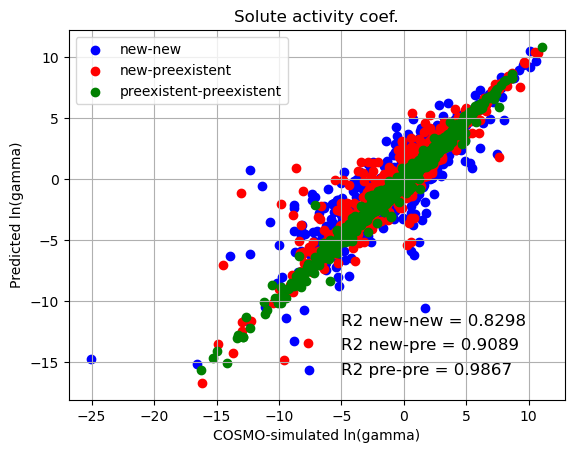

In [14]:
plt.scatter(test_true_nn[2], test_pred_nn[2], color='blue')
plt.scatter(test_true_no[2], test_pred_no[2], color='red')
plt.scatter(test_true_oo[2], test_pred_oo[2], color='green')
plt.grid(axis='both')
plt.xlabel('COSMO-simulated ln(gamma)')
plt.ylabel('Predicted ln(gamma)')
plt.title('Solute activity coef.')
plt.legend(['new-new', 'new-preexistent', 'preexistent-preexistent'])
R2_str_nn = "R2 new-new = {:.4f}".format(R2_nn_solute)
R2_str_no = "R2 new-pre = {:.4f}".format(R2_no_solute)
R2_str_oo = "R2 pre-pre = {:.4f}".format(R2_oo_solute)
plt.text(-5,-12, R2_str_nn, fontsize=12, )
plt.text(-5,-14, R2_str_no, fontsize=12, )
plt.text(-5,-16, R2_str_oo, fontsize=12, )

Text(0, -6, 'R2 pre-pre = 0.9673')

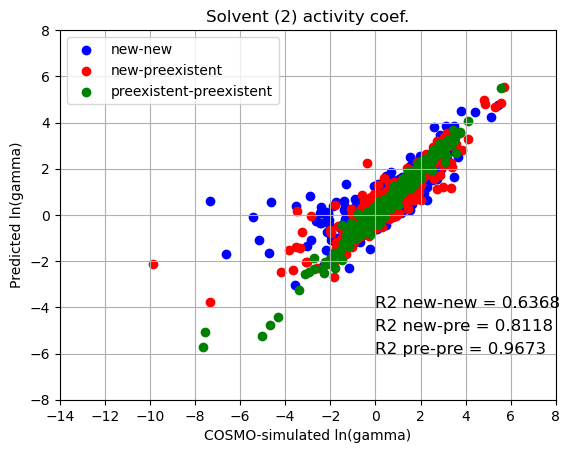

In [15]:
plt.scatter(test_true_nn[1], test_pred_nn[1], color='blue')
plt.scatter(test_true_no[1], test_pred_no[1], color='red')
plt.scatter(test_true_oo[1], test_pred_oo[1], color='green')
plt.grid(axis='both')
plt.xlabel('COSMO-simulated ln(gamma)')
plt.ylabel('Predicted ln(gamma)')
plt.xlim([-14, 8])
plt.ylim([-8,8])
plt.xticks([-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8])
plt.title('Solvent (2) activity coef.')
plt.legend(['new-new', 'new-preexistent', 'preexistent-preexistent'])
R2_str_nn = "R2 new-new = {:.4f}".format(R2_nn_solv2)
R2_str_no = "R2 new-pre = {:.4f}".format(R2_no_solv2)
R2_str_oo = "R2 pre-pre = {:.4f}".format(R2_oo_solv2)
plt.text(0,-4, R2_str_nn, fontsize=12, )
plt.text(0,-5, R2_str_no, fontsize=12, )
plt.text(0,-6, R2_str_oo, fontsize=12, )

Text(-1, -6, 'R2 pre-pre = 0.9455')

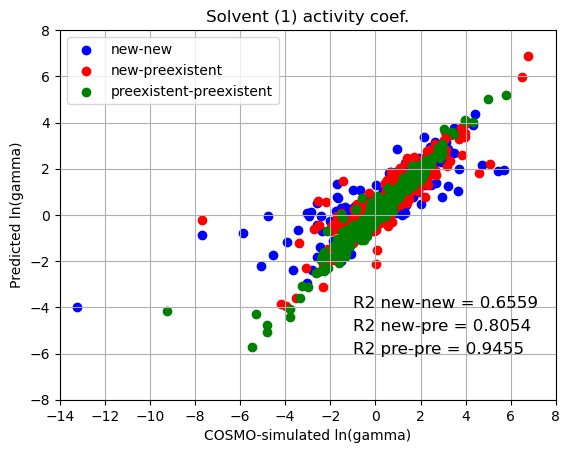

In [16]:
plt.scatter(test_true_nn[0], test_pred_nn[0], color='blue')
plt.scatter(test_true_no[0], test_pred_no[0], color='red')
plt.scatter(test_true_oo[0], test_pred_oo[0], color='green')
plt.grid(axis='both')
plt.xlabel('COSMO-simulated ln(gamma)')
plt.ylabel('Predicted ln(gamma)')
plt.xlim([-14, 8])
plt.ylim([-8,8])
plt.xticks([-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8])
plt.title('Solvent (1) activity coef.')
plt.legend(['new-new', 'new-preexistent', 'preexistent-preexistent'])
R2_str_nn = "R2 new-new = {:.4f}".format(R2_nn_solv1)
R2_str_no = "R2 new-pre = {:.4f}".format(R2_no_solv1)
R2_str_oo = "R2 pre-pre = {:.4f}".format(R2_oo_solv1)
plt.text(-1,-4, R2_str_nn, fontsize=12, )
plt.text(-1,-5, R2_str_no, fontsize=12, )
plt.text(-1,-6, R2_str_oo, fontsize=12, )

Text(0, -6, 'R2 = 0.9731')

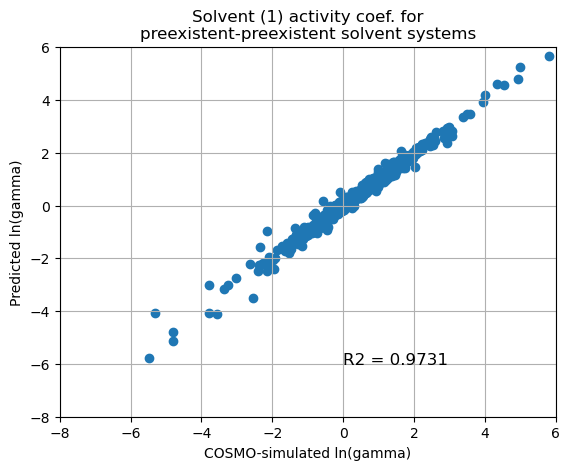

In [126]:
plt.scatter(test_true_oo[0], test_pred_oo[0])
plt.grid(axis='both')
plt.xlabel('COSMO-simulated ln(gamma)')
plt.ylabel('Predicted ln(gamma)')
plt.xlim([-8, 6])
plt.ylim([-8,6])
#plt.xticks([-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8])
plt.title('Solvent (1) activity coef. for\npreexistent-preexistent solvent systems')
R2_str = "R2 = {:.4f}".format(R2_oo_solv1)
plt.text(0,-6, R2_str, fontsize=12, )

Text(-8, 5, 'R2 = 0.8410')

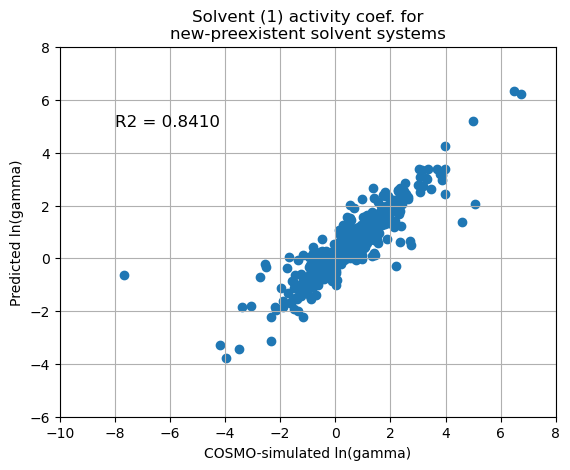

In [135]:
plt.scatter(test_true_no[0], test_pred_no[0])
plt.grid(axis='both')
plt.xlabel('COSMO-simulated ln(gamma)')
plt.ylabel('Predicted ln(gamma)')
plt.xlim([-10, 8])
plt.ylim([-6,8])
#plt.xticks([-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8])
plt.title('Solvent (1) activity coef. for\nnew-preexistent solvent systems')
R2_str = "R2 = {:.4f}".format(R2_no_solv1)
plt.text(-8,5, R2_str, fontsize=12, )

Text(-12, 3, 'R2 = 0.7472')

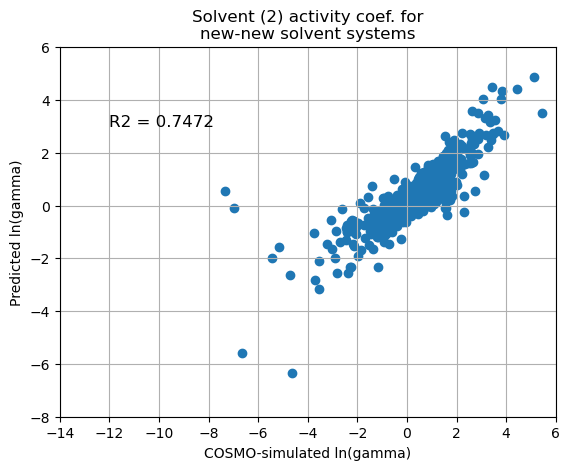

In [139]:
plt.scatter(test_true_nn[1], test_pred_nn[1])
plt.grid(axis='both')
plt.xlabel('COSMO-simulated ln(gamma)')
plt.ylabel('Predicted ln(gamma)')
plt.xlim([-14, 6])
plt.ylim([-8,6])
plt.xticks([-14,-12,-10,-8,-6,-4,-2,0,2,4,6])
plt.title('Solvent (2) activity coef. for\nnew-new solvent systems')
R2_str = "R2 = {:.4f}".format(R2_nn_solv2)
plt.text(-12,3, R2_str, fontsize=12, )